<div style="text-align:center; margin-top:40px;">

<img src="img/python_logo.png" width="550">

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-top:30px;
margin-bottom:10px;
">

3_2_3_Image_segmentation

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
">

16 de julio de 2026

</p>

<h2 style="
font-family:'Times New Roman', serif;
font-size:28px;
font-weight:bold;
margin-top:35px;
">

Procesamiento Digital de Imágenes<br>
Segmentación de Imágenes

</h2>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-top:30px;
margin-bottom:5px;
">

Kevin Xavier Suasnavas Villarreal

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:5px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">

<strong>🔗 Link a mi GitHub:</strong>

https://github.com/kevinsuas433/Machine2026.git

</a>

</p>


</div>

---

# 1. Segmentación de Imágenes

La **segmentación de imágenes** es una técnica fundamental del procesamiento digital de imágenes que permite separar los objetos de interés del fondo o de otras regiones presentes en una escena. Gracias a este proceso es posible facilitar tareas posteriores como el reconocimiento, análisis y clasificación de objetos.

En esta práctica se implementarán diferentes métodos de segmentación utilizando **Python**, **OpenCV** y **Scikit-Image**, entre ellos la segmentación mediante **Thresholding**, la segmentación basada en **espacios de color**, la **detección de bordes** y el **crecimiento de regiones (Region Growing)**. Cada técnica permitirá comprender distintas estrategias para aislar regiones de interés dentro de una imagen.

---

## 1.1 Segmentación mediante Thresholding

La **segmentación por umbralización (Thresholding)** es una de las técnicas más sencillas y utilizadas en el procesamiento digital de imágenes.

Su objetivo consiste en separar los objetos de interés del fondo utilizando un **valor de intensidad (umbral)**. Los píxeles cuyo valor supera el umbral se asignan a una clase, mientras que los restantes pertenecen a otra.

En esta sección se analizará la imagen original, su conversión a escala de grises, el histograma de intensidades y dos métodos de umbralización: un umbral fijo y el método automático de **Otsu**.

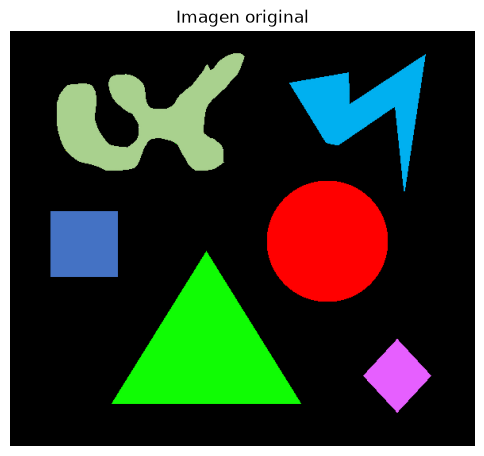

In [1]:
# ==========================================================
# Importación de librerías
# ==========================================================

# Matplotlib permitirá visualizar las imágenes.
import matplotlib.pyplot as plt

# OpenCV será utilizado para cargar y procesar la imagen.
import cv2


# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen original.
img = cv2.imread("images/figuras.png")

# OpenCV utiliza el formato BGR; por ello se convierte a RGB
# para mostrar los colores correctamente con Matplotlib.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ==========================================================
# Visualización de la imagen original
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")
plt.show()

### Conversión a escala de grises

Para aplicar técnicas de umbralización es necesario trabajar con una imagen de un solo canal.

Por ello, la imagen original se convierte a **escala de grises**, donde cada píxel representa únicamente un nivel de intensidad comprendido entre negro y blanco.

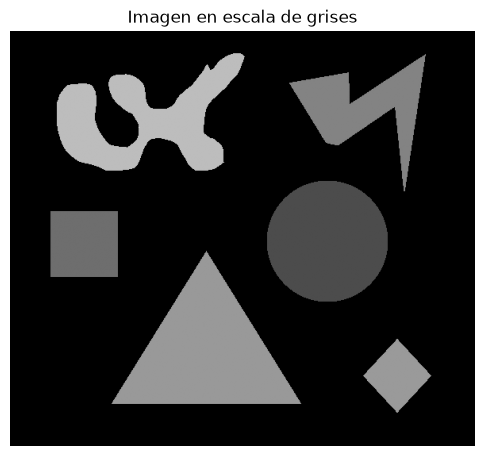

In [2]:
# ==========================================================
# Conversión de la imagen a escala de grises
# ==========================================================

import numpy as np

# Convertimos la imagen RGB a escala de grises.
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# También podría cargarse directamente en escala de grises:
# gray_img = cv2.imread("images/figuras.png", 0)


# ==========================================================
# Visualización de la imagen en escala de grises
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap="gray")
plt.title("Imagen en escala de grises")
plt.axis("off")
plt.show()

### Histograma de intensidades

El histograma representa la distribución de los niveles de intensidad presentes en la imagen.

Su análisis permite identificar posibles regiones correspondientes al fondo y a los objetos, facilitando la selección de un umbral adecuado para realizar la segmentación.

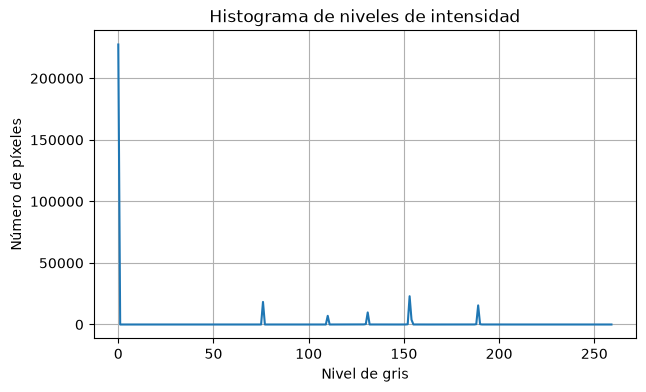

In [3]:
# ==========================================================
# Cálculo del histograma
# ==========================================================

# Calculamos el histograma de la imagen en escala de grises.
hist = cv2.calcHist(
    [gray_img],
    [0],
    None,
    [260],
    [0, 260]
)


# ==========================================================
# Visualización del histograma
# ==========================================================

plt.figure(figsize=(7,4))

plt.plot(hist)

plt.grid(True)

plt.title("Histograma de niveles de intensidad")

plt.xlabel("Nivel de gris")

plt.ylabel("Número de píxeles")

plt.show()

# Otra forma de visualizar el histograma:
# plt.hist(gray_img.ravel(), bins=50)
# plt.grid(True)
# plt.show()

### Segmentación mediante umbral fijo

A partir del histograma se selecciona manualmente un valor de umbral.

Todos los píxeles cuya intensidad sea superior al umbral se asignarán al valor máximo (blanco), mientras que el resto se considerarán parte del fondo (negro), obteniendo así una imagen binaria.

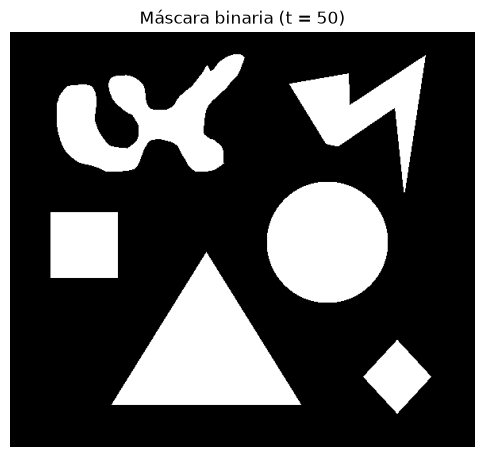

Valores presentes en la máscara: [  0 255]


In [4]:
# ==========================================================
# Segmentación mediante un umbral fijo
# ==========================================================

# Definimos manualmente el valor del umbral.
t = 50

# Valor máximo que tomarán los píxeles segmentados.
maximo = 255


# ==========================================================
# Aplicación del Thresholding
# ==========================================================

_, mask = cv2.threshold(
    gray_img,
    t,
    maximo,
    cv2.THRESH_BINARY
)

# Otra forma de obtener la máscara:
# mask = gray_img > t


# ==========================================================
# Visualización del resultado
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="gray")

plt.title(f"Máscara binaria (t = {t})")

plt.axis("off")

plt.show()


# Mostramos los valores presentes en la máscara.
print("Valores presentes en la máscara:", np.unique(mask))

### Segmentación automática mediante el método de Otsu

El método de **Otsu** calcula automáticamente el valor del umbral que mejor separa el fondo de los objetos presentes en la imagen.

Este procedimiento elimina la necesidad de seleccionar manualmente el umbral, proporcionando una segmentación basada en la distribución estadística de los niveles de intensidad.

Valores presentes en la máscara: [0 1]


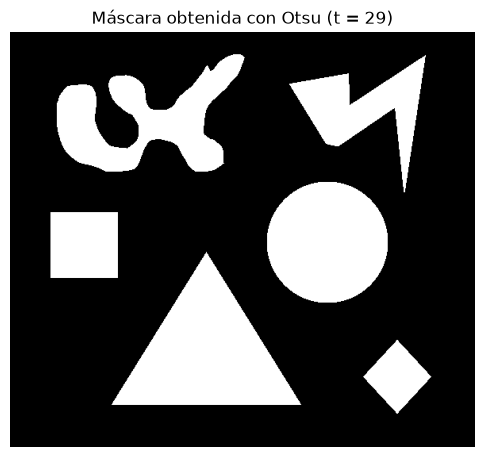

In [5]:
# ==========================================================
# Segmentación mediante el método de Otsu
# ==========================================================

# Aplicamos el algoritmo de Otsu para calcular
# automáticamente el mejor umbral.
t, mask = cv2.threshold(
    gray_img,
    0,
    1,
    cv2.THRESH_OTSU
)


# ==========================================================
# Resultados obtenidos
# ==========================================================

print("Valores presentes en la máscara:", np.unique(mask))


# ==========================================================
# Visualización de la máscara obtenida
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="gray")

plt.title(f"Máscara obtenida con Otsu (t = {t:.0f})")

plt.axis("off")

plt.show()

## 1.2 Segmentación mediante conversiones de color

Además de utilizar la intensidad de los píxeles, es posible segmentar objetos aprovechando la información contenida en los canales de color.

En esta sección se utilizarán los canales de la imagen para aislar objetos específicos según el color que presentan. Posteriormente, se realizará una conversión al espacio de color **CMYK** para extraer una figura mediante uno de sus canales.

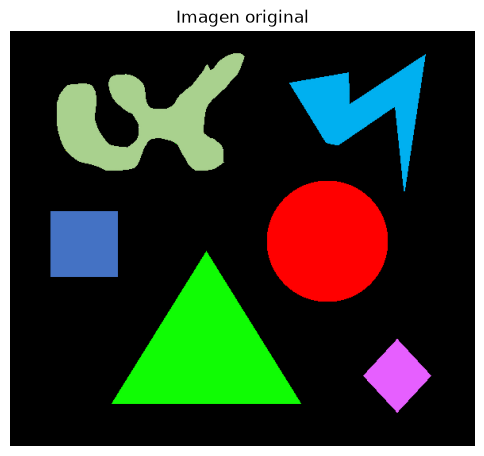

In [6]:
# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen que será utilizada para la segmentación.
img = cv2.imread("images/figuras.png")

# Convertimos la imagen de BGR a RGB para visualizarla correctamente.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ==========================================================
# Visualización de la imagen original
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.title("Imagen original")

plt.axis("off")

plt.show()

### Extracción del canal rojo

Una forma sencilla de segmentar objetos consiste en analizar cada canal de color por separado.

En este caso se extrae el **canal rojo**, ya que el círculo presenta una intensidad elevada en dicho canal, facilitando su separación del resto de figuras.

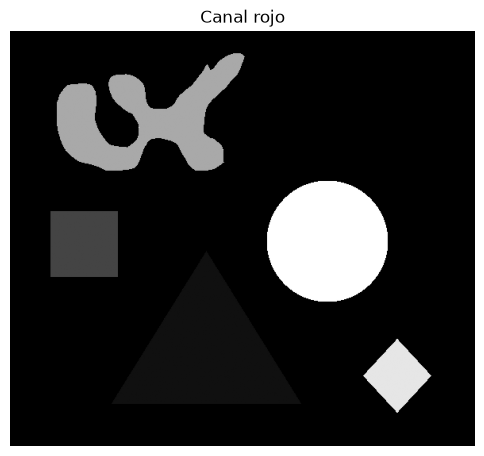

In [7]:
# ==========================================================
# Extracción del canal rojo
# ==========================================================

# OpenCV almacena las imágenes en formato BGR.
# El índice 2 corresponde al canal rojo.
R = img[:, :, 2]


# ==========================================================
# Visualización del canal rojo
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(R, cmap="gray")

plt.title("Canal rojo")

plt.axis("off")

plt.show()

### Histograma del canal rojo

El histograma permite observar la distribución de intensidades presentes en el canal rojo.

A partir de esta información es posible seleccionar un valor de umbral adecuado para segmentar únicamente el objeto de interés.

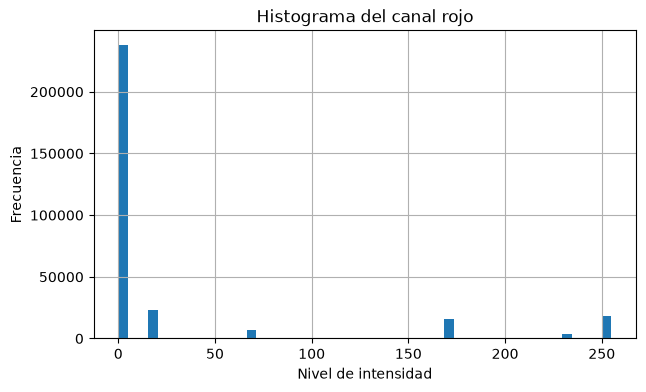

Valor máximo: 255


In [8]:
# ==========================================================
# Histograma del canal rojo
# ==========================================================

plt.figure(figsize=(7,4))

plt.hist(R.ravel(), bins=50)

plt.title("Histograma del canal rojo")

plt.xlabel("Nivel de intensidad")

plt.ylabel("Frecuencia")

plt.grid(True)

plt.show()


# Mostramos el valor máximo presente en el canal.
print("Valor máximo:", np.max(R))

### Segmentación mediante umbral

Una vez identificado el valor máximo del canal rojo, se utiliza como umbral para obtener una máscara binaria que contenga únicamente la figura correspondiente al círculo rojo.

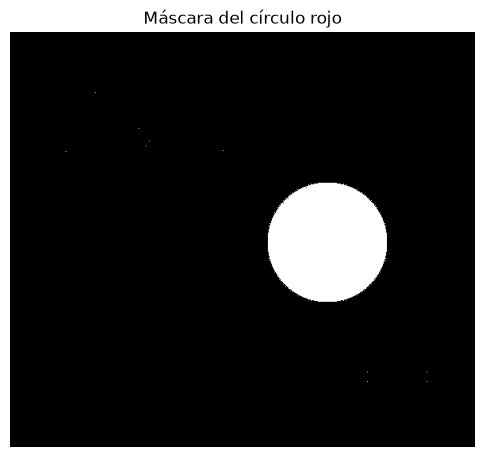

In [9]:
# ==========================================================
# Segmentación del círculo rojo
# ==========================================================

# Utilizamos el valor máximo como umbral.
t = np.max(R)

# Creamos una copia del canal rojo.
mask = R.copy()

# Todos los valores inferiores al umbral se eliminan.
mask[mask < t] = 0


# ==========================================================
# Visualización de la máscara
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="gray")

plt.title("Máscara del círculo rojo")

plt.axis("off")

plt.show()

### Ejercicio: Segmentación del rayo azul mediante el espacio de color CMYK

Como ejercicio complementario, se realizará la conversión de la imagen desde el espacio de color **RGB** al espacio **CMYK**.

Posteriormente, se utilizará el canal **Cyan (C)** para obtener una máscara correspondiente al rayo azul presente en la imagen.

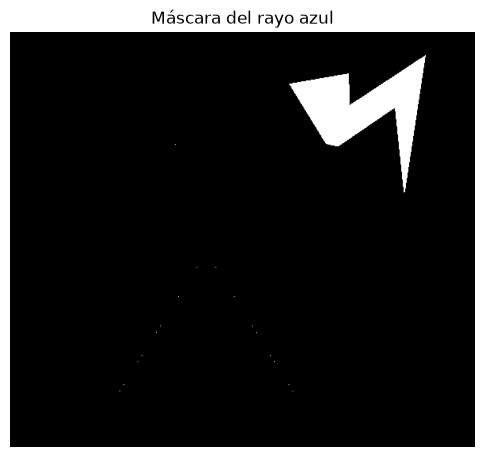

In [10]:
# ==========================================================
# Función para convertir una imagen RGB al espacio CMYK
# ==========================================================

def convert_to_CMYK(rgb_p):

    with np.errstate(invalid="ignore", divide="ignore"):

        K = 1 - np.max(rgb_p, axis=2)

        C = (1 - rgb_p[:, :, 0] - K) / (1 - K)

        M = (1 - rgb_p[:, :, 1] - K) / (1 - K)

        Y = (1 - rgb_p[:, :, 2] - K) / (1 - K)

        CMYK = (np.dstack((C, M, Y, K)) * 255).astype("uint8")

    return CMYK


# ==========================================================
# Lectura de la imagen
# ==========================================================

img = cv2.imread("images/figuras.png")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rgb_p = rgb.astype("float32") / 255


# ==========================================================
# Conversión al espacio CMYK
# ==========================================================

CMYK = convert_to_CMYK(rgb_p)


# ==========================================================
# Separación de canales
# ==========================================================

C, M, Y, K = cv2.split(CMYK)

C = C.astype("uint8")


# ==========================================================
# Segmentación del rayo azul
# ==========================================================

# Utilizamos un umbral sobre el canal Cyan.
mask = C.copy()

mask[mask < np.max(C)] = 0


# ==========================================================
# Visualización de la máscara
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(mask, cmap="gray")

plt.title("Máscara del rayo azul")

plt.axis("off")

plt.show()

## 1.3 Segmentación semántica mediante detección de bordes

Otra estrategia para segmentar objetos consiste en detectar sus bordes. En lugar de analizar únicamente la intensidad o el color de los píxeles, este método identifica los cambios bruscos de intensidad que delimitan los contornos de los objetos.

En esta práctica se utilizará el detector de bordes de **Canny**, uno de los algoritmos más empleados en visión por computador debido a su precisión y robustez frente al ruido.

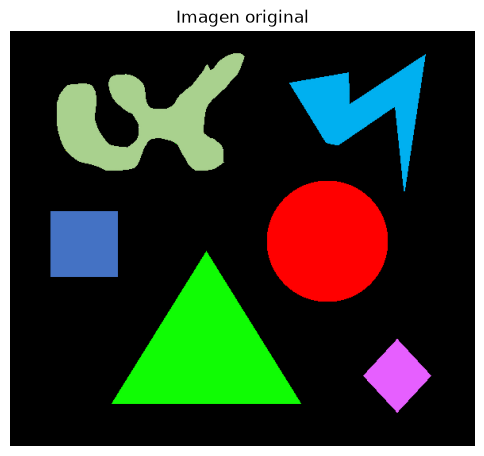

In [11]:
# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen que será utilizada para la detección
# de bordes.
img = cv2.imread("images/figuras.png")

# Convertimos la imagen al espacio RGB para visualizarla
# correctamente con Matplotlib.
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


# ==========================================================
# Visualización de la imagen original
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(img_rgb)

plt.title("Imagen original")

plt.axis("off")

plt.show()

### Suavizado mediante filtro Gaussiano

Antes de detectar los bordes es recomendable aplicar un filtro de suavizado para reducir el ruido presente en la imagen.

En este caso se utiliza un **Filtro Gaussiano**, el cual atenúa las altas frecuencias y mejora el rendimiento del detector de Canny.

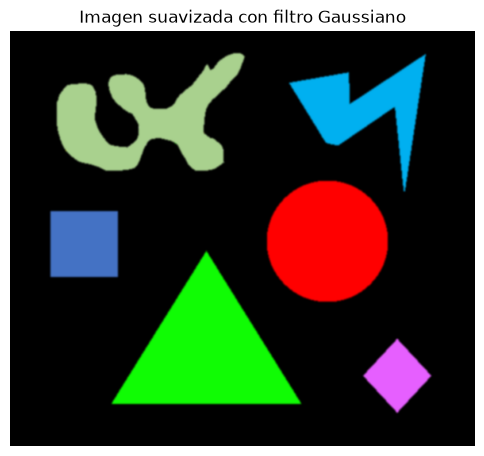

In [12]:
# ==========================================================
# Aplicación del filtro Gaussiano
# ==========================================================

# Aplicamos un filtro Gaussiano de tamaño 5x5 para reducir
# el ruido presente en la imagen.
img_gaus = cv2.GaussianBlur(
    img_rgb,
    (5, 5),
    0
)


# ==========================================================
# Visualización del resultado
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(img_gaus)

plt.title("Imagen suavizada con filtro Gaussiano")

plt.axis("off")

plt.show()

### Detección de bordes mediante Canny

El algoritmo **Canny** detecta los contornos presentes en la imagen utilizando el gradiente de intensidad.

Para ello emplea dos umbrales que permiten conservar únicamente los bordes más representativos, reduciendo la influencia del ruido y de pequeñas variaciones de intensidad.

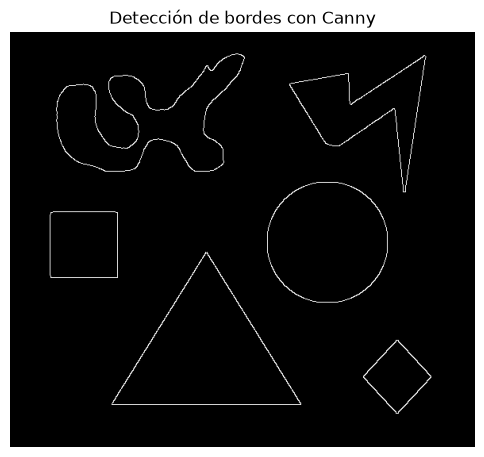

In [18]:
# ==========================================================
# Detección de bordes mediante Canny
# ==========================================================

# Aplicamos el detector de bordes de Canny.
# Se utilizan dos umbrales:
# - Umbral inferior: 255 / 3
# - Umbral superior: 255
canny = cv2.Canny(
    img_gaus,
    255 / 3,
    255
)


# ==========================================================
# Operaciones morfológicas (opcionales)
# ==========================================================

# Kernel utilizado para operaciones morfológicas.
kernel = np.ones((2, 2), dtype="uint8")

# Si fuera necesario pueden utilizarse estas operaciones
# para unir o eliminar pequeños bordes.

# canny = cv2.dilate(canny, kernel, iterations=2)
# canny = cv2.erode(canny, kernel, iterations=2)


# ==========================================================
# Visualización de los bordes detectados
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(canny, cmap="gray")

plt.title("Detección de bordes con Canny")

plt.axis("off")

plt.show()

### Relleno de regiones

Una vez obtenidos los bordes, es posible rellenar las regiones cerradas para generar una máscara binaria de los objetos.

La función **binary_fill_holes** permite completar el interior de las figuras siempre que sus contornos estén completamente cerrados y no estén conectados con el borde de la imagen.

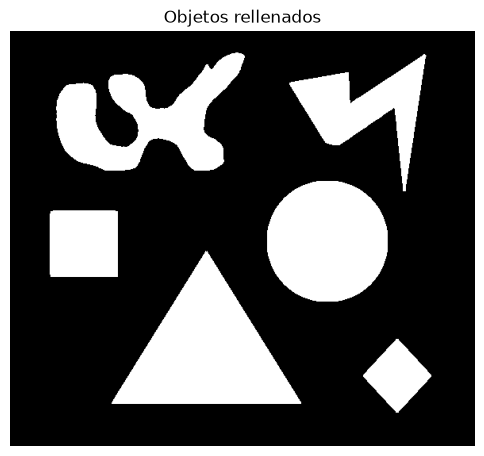

In [14]:
# ==========================================================
# Relleno de regiones cerradas
# ==========================================================

# Importamos la función que permite rellenar el interior
# de los objetos delimitados por bordes cerrados.
from scipy.ndimage import binary_fill_holes


# ==========================================================
# Aplicación del relleno
# ==========================================================

# Creamos una copia de la imagen de bordes.
bordes = canny.copy()

# Rellenamos las regiones cerradas.
filled_bordes = binary_fill_holes(bordes)


# ==========================================================
# Visualización del resultado
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(filled_bordes.astype("uint8"), cmap="gray")

plt.title("Objetos rellenados")

plt.axis("off")

plt.show()

## 1.4 Segmentación por crecimiento de regiones (Region Growing)

El **crecimiento de regiones (Region Growing)** es una técnica de segmentación que agrupa píxeles vecinos con características similares a partir de un punto inicial denominado **semilla** (*seed*).

El algoritmo comienza en la semilla y expande progresivamente la región mientras los píxeles vecinos cumplen determinados criterios de similitud. En OpenCV, este procedimiento puede implementarse mediante la función **Flood Fill**, que rellena automáticamente una región conectada.

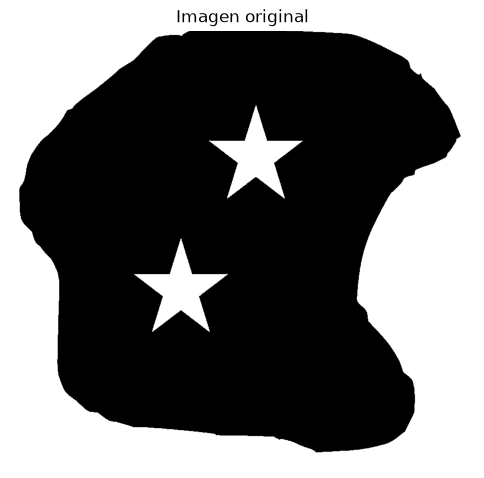

In [15]:
# ==========================================================
# Importación de librerías
# ==========================================================

# Scikit-Image se utiliza para la lectura de imágenes.
from skimage import io

# OpenCV permite realizar el crecimiento de regiones.
import cv2

# NumPy facilita el manejo de matrices.
import numpy as np

# Matplotlib se utilizará para visualizar los resultados.
import matplotlib.pyplot as plt


# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen en escala de grises.
img = cv2.imread("images/estrellas.png", 0)


# ==========================================================
# Visualización de la imagen original
# ==========================================================

plt.figure(figsize=(6,6))

plt.imshow(img, cmap="gray")

plt.title("Imagen original")

plt.axis("off")

plt.show()

### Aplicación del algoritmo Flood Fill

Para realizar el crecimiento de regiones se crea una copia de la imagen y una máscara auxiliar requerida por OpenCV.

Posteriormente, se define una **semilla** ubicada en la esquina superior izquierda de la imagen. A partir de este punto, el algoritmo rellena automáticamente todos los píxeles conectados que presentan características similares, generando la máscara segmentada.

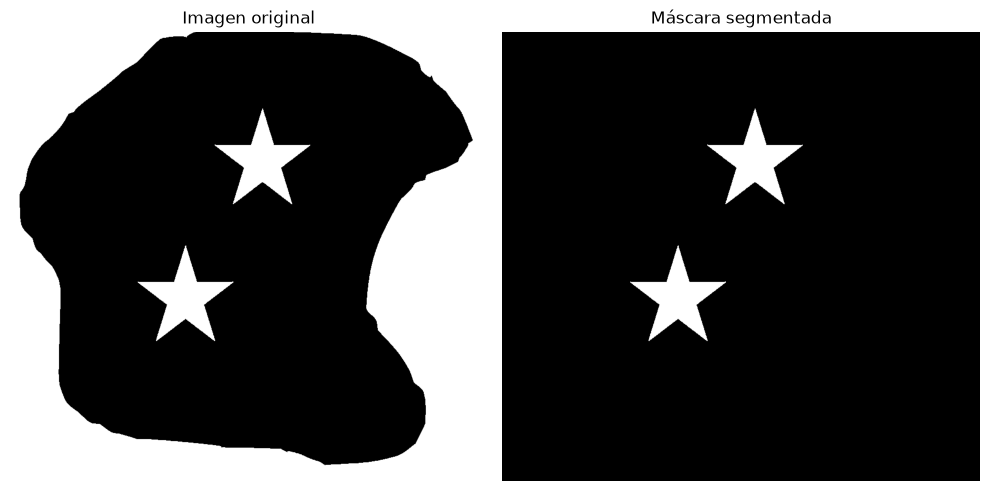

In [16]:
# ==========================================================
# Segmentación mediante crecimiento de regiones
# ==========================================================

# Creamos una copia de la imagen para no modificar el original.
mask = img.copy()


# ==========================================================
# Creación de la máscara auxiliar
# ==========================================================

# Obtenemos las dimensiones de la imagen.
h, w = img.shape

# FloodFill requiere una imagen auxiliar dos píxeles más
# grande que la imagen original.
ref = np.zeros((h + 2, w + 2), dtype=np.uint8)


# ==========================================================
# Definición de la semilla
# ==========================================================

# La semilla se ubica en la esquina superior izquierda.
seed = (0, 0)


# ==========================================================
# Aplicación del algoritmo Flood Fill
# ==========================================================

# Se rellenan con el valor 0 todos los píxeles conectados
# a la semilla seleccionada.
cv2.floodFill(
    mask,
    ref,
    seed,
    0
)


# ==========================================================
# Visualización de resultados
# ==========================================================

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Imagen original
ax[0].imshow(img, cmap="gray")
ax[0].set_title("Imagen original")
ax[0].axis("off")

# Resultado de la segmentación
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Máscara segmentada")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## Conclusión

En esta práctica se implementaron diferentes técnicas de segmentación de imágenes utilizando Python y OpenCV. Se analizaron métodos basados en **umbralización**, **espacios de color**, **detección de bordes** y **crecimiento de regiones**, observando cómo cada uno permite separar objetos de interés según distintas características de la imagen.

La segmentación constituye una etapa fundamental dentro del procesamiento digital de imágenes, ya que facilita tareas posteriores como la extracción de características, el reconocimiento de objetos y la clasificación automática en aplicaciones de visión por computador.